<p align="center" style="font-size:24px;"><b>HW 7 - Multi-class and Multi-label Classification</b></p>


## 1. Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [121]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, calinski_harabasz_score, hamming_loss
from sklearn.cluster import KMeans

from imblearn.over_sampling import SMOTE

import warnings
from sklearn.exceptions import ConvergenceWarning

# to suppress convergence warning in SMOTE+L1SVM
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

from collections import Counter

### (a) Download the Anuran Calls (MFCCs) Data Set

In [122]:
data_path = "../data/anuran+calls+mfccs/Frogs_MFCCs.csv"
df = pd.read_csv(data_path)

print(df.shape)

(7195, 26)


In [123]:
# train 70%, test 30%
train_df, test_df = train_test_split(
    df,
    train_size=0.7,
    random_state=11
)

print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)

feature_cols = [col for col in df.columns if col.startswith("MFCCs_")]
label_cols = ["Family", "Genus", "Species"]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

y_train = train_df[label_cols]
y_test  = test_df[label_cols]

print("X_train sample preview:")
display(X_train.head())

print("y_train sample preview:")
display(y_train.head())

Train shape:  (5036, 26)
Test shape:  (2159, 26)
X_train sample preview:


,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
6426,1.0,0.196996,0.313317,0.332359,0.207997,0.152874,0.109425,-0.122868,-0.045095,0.121588,...,0.112961,-0.034055,-0.144950,0.004881,0.110089,0.011443,-0.023581,0.004290,-0.056549,-0.027948
5467,1.0,0.522453,0.589259,0.419772,0.123452,0.234466,0.058643,0.163593,0.114152,-0.180925,...,-0.061318,-0.155157,0.097805,-0.019264,-0.084852,0.103693,0.136892,0.110013,0.064635,-0.049919
5735,1.0,0.479763,0.439725,0.242858,0.044070,0.130780,0.021028,-0.007029,0.102527,0.065463,...,0.088866,-0.007499,-0.047529,0.055878,0.048624,0.006919,0.018040,-0.012685,-0.001698,0.048207
4092,1.0,0.236711,0.209358,0.562521,0.169576,0.018251,-0.099487,0.098595,0.308062,0.016464,...,0.383664,-0.085741,-0.245523,0.056815,0.184270,0.051194,-0.078421,-0.185642,0.009679,0.225990
2866,1.0,0.294628,0.188838,0.509159,0.240478,0.068142,-0.129314,-0.006540,0.260868,0.075513,...,0.347443,0.021462,-0.251619,-0.013836,0.193233,0.091220,-0.059981,-0.151648,-0.016991,0.177048


y_train sample preview:


,Family,Genus,Species
6426,Hylidae,Hypsiboas,HypsiboasCordobae
5467,Hylidae,Hypsiboas,HypsiboasCinerascens
5735,Hylidae,Hypsiboas,HypsiboasCordobae
4092,Leptodactylidae,Adenomera,AdenomeraHylaedactylus
2866,Leptodactylidae,Adenomera,AdenomeraHylaedactylus


### (b) Train a classifier for each label

#### (i) Research

**Exact Match** is a stricter version of accuracy where all labels have to match exactly for the sample to be correctly classified. In our cases, an instance will receive a score of 1 when Family, Genus and Species are all predicted correctly otherwise 0.

**Hamming score** is a Classification metric featuring a fraction of the predictions that a model got right. It evaluates each label independently and rewards partial correctness.

#### (ii) Train a SVM for each of the labels

For raw data and standardized data, we will do the following steps:

- Step 1: Find a proper range of λ to improve efficiency

    - generate a wide range of λ (C) values
    - look for a proper range of λ with >= 70% accuracy
    - inside this range, choose 20 candidates

- Step 2: Find a proper range of σ to improve efficiency

    - generate a wide range of σ values
    - look for a proper range of σ with >= 70% accuracy
    - inside this range, choose 20 candidates
    - in sklearn, the Gaussian kernel width σ will be transferred to $γ = 1/(2σ^2)$

- Step 3: apply GridSearch CV(10-fold) to the data using the shrinked range

    for each label:
    - use cross validation to find best λ and σ
    - find best parameters and best accuracy

After repeating the same steps on raw and standardized data, we will compare the best λ and σ and the best accuracy.

In [124]:
threshold = 0.70
n_initial = 30
n_final = 20

# step 1
print("=== Raw: Step 1 - C range ===")

C_initial_raw = 10 ** np.linspace(-6, 6, n_initial)
training_acc_C_raw = []

for C in C_initial_raw:
    clf = SVC(kernel="rbf", C=C, gamma=1)
    clf.fit(X_train, y_train["Family"])
    acc = accuracy_score(y_train["Family"], clf.predict(X_train))
    training_acc_C_raw.append(acc)

valid_C_raw = [C for C, acc in zip(C_initial_raw, training_acc_C_raw) if acc >= threshold]

if len(valid_C_raw) == 0:
    print("Raw: no C satisfies threshold, using full range.")
    C_min_raw, C_max_raw = C_initial_raw[0], C_initial_raw[-1]
else:
    C_min_raw, C_max_raw = min(valid_C_raw), max(valid_C_raw)

C_candidates_raw = 10 ** np.linspace(np.log10(C_min_raw), np.log10(C_max_raw), n_final)
print(f"Raw: shrinked C range: [{C_min_raw:.2e}, {C_max_raw:.2e}]")

# step 2
print("=== Raw: Step 2 - sigma/gamma range ===")

sigma_initial_raw = np.linspace(0.05, 5.0, n_initial)
gamma_initial_raw = [1 / (2 * s**2) for s in sigma_initial_raw]
training_acc_gamma_raw = []

for g in gamma_initial_raw:
    clf = SVC(kernel="rbf", C=1, gamma=g)
    clf.fit(X_train, y_train["Family"])
    acc = accuracy_score(y_train["Family"], clf.predict(X_train))
    training_acc_gamma_raw.append(acc)

valid_sigma_raw = [s for s, acc in zip(sigma_initial_raw, training_acc_gamma_raw) if acc >= threshold]

if len(valid_sigma_raw) == 0:
    print("RAW: no sigma reaches threshold, using full range.")
    s_min_raw, s_max_raw = sigma_initial_raw[0], sigma_initial_raw[-1]
else:
    s_min_raw, s_max_raw = min(valid_sigma_raw), max(valid_sigma_raw)

sigma_final_raw = np.linspace(s_min_raw, s_max_raw, n_final)
gamma_candidates_raw = [1 / (2 * s**2) for s in sigma_final_raw]

print(f"RAW valid sigma range: [{s_min_raw:.3f}, {s_max_raw:.3f}]")


=== Raw: Step 1 - C range ===
Raw: shrinked C range: [5.30e-03, 1.00e+06]
=== Raw: Step 2 - sigma/gamma range ===
RAW valid sigma range: [0.050, 5.000]


In [125]:
# step 3
print("=== Raw: Step 3 - GridSearchCV ===")

results_raw = {}

for label in label_cols:
    print(f"Raw GridSearch for label: {label}...")
    y = y_train[label]

    param_grid_raw = {
        "C": C_candidates_raw,
        "gamma": gamma_candidates_raw
    }

    svm = SVC(kernel="rbf")

    grid = GridSearchCV(
        svm,
        param_grid_raw,
        scoring="accuracy",
        cv=10,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_train, y)
    best_params = grid.best_params_
    best_score = grid.best_score_

    C_best = best_params["C"]
    gamma_best = best_params["gamma"]
    sigma_best = (1 / (2 * gamma_best)) ** 0.5

    results_raw[label] = (best_params, best_score)

    print(f"Best C      = {C_best:.4f}")
    print(f"Best gamma  = {gamma_best:.4f}")
    print(f"Best sigma  = {sigma_best:.4f}")
    print(f"Best CV acc = {best_score:.4f}")


=== Raw: Step 3 - GridSearchCV ===
Raw GridSearch for label: Family...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 16.1701
Best gamma  = 1.5333
Best sigma  = 0.5711
Best CV acc = 0.9932
Raw GridSearch for label: Genus...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 120.1863
Best gamma  = 1.5333
Best sigma  = 0.5711
Best CV acc = 0.9917
Raw GridSearch for label: Species...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 44.0842
Best gamma  = 1.5333
Best sigma  = 0.5711
Best CV acc = 0.9917


In [126]:
# Build standardized version of X_train
scaler_for_range = StandardScaler()
X_train_std_for_range = scaler_for_range.fit_transform(X_train)

print("=== STD: Step 1 - C range ===")

C_initial_std = 10 ** np.linspace(-6, 6, n_initial)
training_acc_C_std = []

for C in C_initial_std:
    clf = SVC(kernel="rbf", C=C, gamma=1)
    clf.fit(X_train_std_for_range, y_train["Family"])
    acc = accuracy_score(y_train["Family"], clf.predict(X_train_std_for_range))
    training_acc_C_std.append(acc)

valid_C_std = [C for C, acc in zip(C_initial_std, training_acc_C_std) if acc >= threshold]

if len(valid_C_std) == 0:
    print("STD: no C satisfies threshold, using full range.")
    C_min_std, C_max_std = C_initial_std[0], C_initial_std[-1]
else:
    C_min_std, C_max_std = min(valid_C_std), max(valid_C_std)

C_candidates_std = 10 ** np.linspace(np.log10(C_min_std), np.log10(C_max_std), n_final)
print(f"STD valid C range: [{C_min_std:.2e}, {C_max_std:.2e}]")


print("=== STD: Step 2 - sigma/gamma range ===")

sigma_initial_std = np.linspace(0.05, 5.0, n_initial)
gamma_initial_std = [1 / (2 * s**2) for s in sigma_initial_std]
training_acc_gamma_std = []

for g in gamma_initial_std:
    clf = SVC(kernel="rbf", C=1, gamma=g)
    clf.fit(X_train_std_for_range, y_train["Family"])
    acc = accuracy_score(y_train["Family"], clf.predict(X_train_std_for_range))
    training_acc_gamma_std.append(acc)

valid_sigma_std = [s for s, acc in zip(sigma_initial_std, training_acc_gamma_std) if acc >= threshold]

if len(valid_sigma_std) == 0:
    print("STD: no sigma reaches threshold, using full range.")
    s_min_std, s_max_std = sigma_initial_std[0], sigma_initial_std[-1]
else:
    s_min_std, s_max_std = min(valid_sigma_std), max(valid_sigma_std)

sigma_final_std = np.linspace(s_min_std, s_max_std, n_final)
gamma_candidates_std = [1 / (2 * s**2) for s in sigma_final_std]

print(f"STD valid sigma range: [{s_min_std:.3f}, {s_max_std:.3f}]")


=== STD: Step 1 - C range ===
STD valid C range: [3.56e-02, 1.00e+06]
=== STD: Step 2 - sigma/gamma range ===
STD valid sigma range: [0.050, 5.000]


In [127]:
print("=== STD: Step 3 - GridSearchCV ===")
results_std = {}

for label in label_cols:
    print(f"STD GridSearch for label: {label}...")
    y = y_train[label]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ])

    param_grid_std = {
        "svm__C": C_candidates_std,
        "svm__gamma": gamma_candidates_std
    }

    grid = GridSearchCV(
        pipe,
        param_grid_std,
        scoring="accuracy",
        cv=10,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_train, y)
    best_params = grid.best_params_
    best_score = grid.best_score_

    C_best = best_params["svm__C"]
    gamma_best = best_params["svm__gamma"]
    sigma_best = (1 / (2 * gamma_best)) ** 0.5

    results_std[label] = (best_params, best_score)

    print(f"Best C      = {C_best:.4f}")
    print(f"Best gamma  = {gamma_best:.4f}")
    print(f"Best sigma  = {sigma_best:.4f}")
    print(f"Best CV acc = {best_score:.4f}")


=== STD: Step 3 - GridSearchCV ===
STD GridSearch for label: Family...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 19.7618
Best gamma  = 0.0588
Best sigma  = 2.9158
Best CV acc = 0.9938
STD GridSearch for label: Genus...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 48.7349
Best gamma  = 0.0423
Best sigma  = 3.4368
Best CV acc = 0.9917
STD GridSearch for label: Species...
Fitting 10 folds for each of 400 candidates, totalling 4000 fits
Best C      = 8.0133
Best gamma  = 0.0423
Best sigma  = 3.4368
Best CV acc = 0.9901


In [128]:
print("--- Raw data ---")
for label, (params, score) in results_raw.items():
    C = params["C"]
    gamma = params["gamma"]
    sigma = (1 / (2 * gamma)) ** 0.5
    print(f"{label:8s}      C = {C:.4f}, gamma = {gamma:.4f}, sigma = {sigma:.4f}, CV acc = {score:.4f}")

print("--- Standaradized data ---")
for label, (params, score) in results_std.items():
    C = params["svm__C"]
    gamma = params["svm__gamma"]
    sigma = (1 / (2 * gamma)) ** 0.5
    print(f"{label:8s}      C = {C:.4f}, gamma = {gamma:.4f}, sigma = {sigma:.4f}, CV acc = {score:.4f}")


--- Raw data ---
Family        C = 16.1701, gamma = 1.5333, sigma = 0.5711, CV acc = 0.9932
Genus         C = 120.1863, gamma = 1.5333, sigma = 0.5711, CV acc = 0.9917
Species       C = 44.0842, gamma = 1.5333, sigma = 0.5711, CV acc = 0.9917
--- Standaradized data ---
Family        C = 19.7618, gamma = 0.0588, sigma = 2.9158, CV acc = 0.9938
Genus         C = 48.7349, gamma = 0.0423, sigma = 3.4368, CV acc = 0.9917
Species       C = 8.0133, gamma = 0.0423, sigma = 3.4368, CV acc = 0.9901


After obtaining the parameters for the optimal model for raw and standardized data, we will re-fit the model and calculate the exact match and the hamming score based on the test set.

In [129]:
final_models_raw = {}

for label in label_cols:
    best_params = results_raw[label][0]
    C_best = best_params["C"]
    gamma_best = best_params["gamma"]

    clf = SVC(kernel="rbf", C=C_best, gamma=gamma_best)
    clf.fit(X_train, y_train[label])
    final_models_raw[label] = clf

pred_raw = pd.DataFrame()

for label in label_cols:
    pred_raw[label] = final_models_raw[label].predict(X_test)

In [130]:
final_models_std = {}

for label in label_cols:
    best_params = results_std[label][0]
    C_best = best_params["svm__C"]
    gamma_best = best_params["svm__gamma"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C_best, gamma=gamma_best))
    ])
    pipe.fit(X_train, y_train[label])
    final_models_std[label] = pipe

pred_std = pd.DataFrame()

for label in label_cols:
    pred_std[label] = final_models_std[label].predict(X_test)

In [131]:
y_true = y_test[label_cols].to_numpy()
y_pred_raw_mat = pred_raw[label_cols].to_numpy()
y_pred_std_mat = pred_std[label_cols].to_numpy()

def exact_match_score(y_true, y_pred):
    return np.mean(np.all(y_true == y_pred, axis=1))

def hamming_score(y_true, y_pred):
    return 1 - np.mean(y_true != y_pred)

exact_raw = exact_match_score(y_true, y_pred_raw_mat)
hamming_raw = hamming_score(y_true, y_pred_raw_mat)

exact_std = exact_match_score(y_true, y_pred_std_mat)
hamming_std = hamming_score(y_true, y_pred_std_mat)

print("=== Multi-label Evaluation on Test Set ===")
print(f"Raw         : Exact Match = {exact_raw:.4f}, Hamming Score = {hamming_raw:.4f}")
print(f"Standardized: Exact Match = {exact_std:.4f}, Hamming Score = {hamming_std:.4f}")


=== Multi-label Evaluation on Test Set ===
Raw         : Exact Match = 0.9838, Hamming Score = 0.9893
Standardized: Exact Match = 0.9833, Hamming Score = 0.9897


We can see from the result that the model trained by raw data and standardized data don't have too much difference between performances. Since the data is already normalized, the standardization didn't make a lot of change to the data. We will continue the following steps using the standardized data because it generally can produce more stable behavior.

#### (iii) Repeat 1(b)ii with L1-penalized SVMs

Here we don't need to shrink the range, because L1-penalized SVMs only have one parameter C. We can directly choose 20 candidates.

In [132]:
C_values_l1 = 10 ** np.linspace(-4, 4, 20)

print("=== L1-SVM: GridSearchCV on std data ===")

results_l1 = {}

for label in label_cols:
    print(f"L1-SVM GridSearch for label: {label}...")
    y = y_train[label]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("l1_svm", LinearSVC(penalty="l1", loss="squared_hinge", dual=False, max_iter=5000))
    ])

    param_grid_l1 = {
        "l1_svm__C": C_values_l1
    }

    grid = GridSearchCV(
        pipe,
        param_grid_l1,
        scoring="accuracy",
        cv=10,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_train, y)
    best_params = grid.best_params_
    best_score = grid.best_score_

    results_l1[label] = (best_params, best_score)

    print(f"Best C      = {best_params['l1_svm__C']:.4f}")
    print(f"Best CV acc = {best_score:.4f}\n")



=== L1-SVM: GridSearchCV on std data ===
L1-SVM GridSearch for label: Family...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 0.6158
Best CV acc = 0.9380

L1-SVM GridSearch for label: Genus...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 11.2884
Best CV acc = 0.9535

L1-SVM GridSearch for label: Species...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 11.2884
Best CV acc = 0.9617



In [133]:
# refit models using best C
final_models_l1 = {}

for label in label_cols:
    C_best = results_l1[label][0]["l1_svm__C"]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("l1_svm", LinearSVC(penalty="l1", loss="squared_hinge", dual=False, C=C_best, max_iter=5000))
    ])

    pipe.fit(X_train, y_train[label])
    final_models_l1[label] = pipe

pred_l1 = pd.DataFrame()

for label in label_cols:
    pred_l1[label] = final_models_l1[label].predict(X_test)


In [134]:
y_pred_l1_mat = pred_l1[label_cols].to_numpy()

exact_l1 = exact_match_score(y_true, y_pred_l1_mat)
hamming_l1 = hamming_score(y_true, y_pred_l1_mat)

print("=== L1-SVM Multi-label Evaluation on Test Set ===")
print(f"L1-SVM: Exact Match = {exact_l1:.4f}, Hamming Score = {hamming_l1:.4f}")


=== L1-SVM Multi-label Evaluation on Test Set ===
L1-SVM: Exact Match = 0.9129, Hamming Score = 0.9440


Compare the results from L1-SVM and the SVM model in (b)ii, we can see L1-SVM has lower performance. It is because L1-SVM is linear model where it cannot capture non-linear patterns of MFCC. Also it is lack of flexibility when fitting the model, so L1-SVM is underfitting in this case.

#### (iv) Repeat 1(b)iii by using SMOTE or any other method for imbalance

- Step 1: apply SMOTE to data of each label
- Step 2: train L1-SVM model using adjusted data
- Step 3: use 10-fold GridSearchCV to find best C
- Step 4: evaluate the optimal model on test data

In [135]:
print("=== SMOTE + L1-SVM: GridSearchCV on std data ===")

results_l1_smote = {}
final_models_l1_smote = {}

for label in label_cols:
    print(f"SMOTE + L1-SVM for label: {label}...")

    smote = SMOTE(random_state=11)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train[label])

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("l1_svm", LinearSVC(penalty="l1", loss="squared_hinge", 
                             dual=False, max_iter=5000))
    ])

    param_grid_l1 = {
        "l1_svm__C": C_values_l1
    }

    grid = GridSearchCV(
        pipe,
        param_grid_l1,
        scoring="accuracy",
        cv=10,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_resampled, y_resampled)

    best_params = grid.best_params_
    best_score = grid.best_score_
    results_l1_smote[label] = (best_params, best_score)

    print(f"Best C      = {best_params['l1_svm__C']:.4f}")
    print(f"Best CV acc = {best_score:.4f}")

    best_C = best_params["l1_svm__C"]
    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("l1_svm", LinearSVC(penalty="l1", loss="squared_hinge",
                             dual=False, C=best_C, max_iter=5000))
    ])
    pipe_best.fit(X_resampled, y_resampled)
    final_models_l1_smote[label] = pipe_best


pred_l1_smote = pd.DataFrame()

for label in label_cols:
    pred_l1_smote[label] = final_models_l1_smote[label].predict(X_test)

y_pred_l1_smote_mat = pred_l1_smote[label_cols].to_numpy()

exact_l1_smote = exact_match_score(y_true, y_pred_l1_smote_mat)
hamming_l1_smote = hamming_score(y_true, y_pred_l1_smote_mat)

print("\n=== SMOTE + L1-SVM Multi-label Evaluation ===")
print(f"SMOTE + L1-SVM: Exact Match = {exact_l1_smote:.4f}, Hamming Score = {hamming_l1_smote:.4f}")

=== SMOTE + L1-SVM: GridSearchCV on std data ===
SMOTE + L1-SVM for label: Family...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 1.6238
Best CV acc = 0.9494
SMOTE + L1-SVM for label: Genus...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 4.2813
Best CV acc = 0.9588
SMOTE + L1-SVM for label: Species...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best C      = 78.4760
Best CV acc = 0.9594

=== SMOTE + L1-SVM Multi-label Evaluation ===
SMOTE + L1-SVM: Exact Match = 0.8638, Hamming Score = 0.9273


Compare the result, using SMOTE + L1-SVM didn't improve the exact match and hamming score. These values are become lower.

This is expected because SMOTE generates synthetic samples and improves the imbalance of the dataset. But L1-SVM is a linear model, it cannot fit well to the non-linear data. And because SMOTE adds more generality to the data, it makes sense that the L1-SVM will perform worse. This confirms that the non-linear MFCC data cannot be fitted well by a linear model. 

## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

In this problem, we will run a 50-time for loop to follow the Monte-Carlo simulation, and in each loop i, we will:
- compute CH(k) for k = 2,3,...,50 to choose the best k_i
- run KMeans(best k_i) to generate majority labels
- compute Hamming distance, Hamming score, and Hamming loss for current cluster

Since it can be covered in one loop to complete the tasks in (a), (b) and (c), we will run the code in one block. For each run, I will print the result as answer to (a), (b) and (c) separately.

And we will use CH score to evaluate the performance of different k. Note that the formula of CH score is,

$$CH(k) = \frac{B/(k-1)}{W/(n-k)}$$

When k=1, there is only one cluster, the denominator will be 0 which is meaningless. So we will skip k=1 and start from k=2.

In [136]:
feature_cols = [c for c in df.columns if c.startswith("MFCCs_")]
X = df[feature_cols].to_numpy()

label_cols = ["Family", "Genus", "Species"]
Y_true = df[label_cols].to_numpy()

def single_run(run_id):

    print("==============")
    print(f"Monte-Carlo Run {run_id}")

    # 2(a) Find best k using CH score
    k_values = range(2, 51)
    ch_scores = []

    for k in k_values:
        km = KMeans(n_clusters=k, init="random", n_init=1, random_state=run_id)
        labels = km.fit_predict(X)
        ch_scores.append(calinski_harabasz_score(X, labels))

    best_k = k_values[np.argmax(ch_scores)]
    print(f"Optimal k = {best_k}")

    # 2(b) KMeans(best_k) + majority labels
    km_final = KMeans(n_clusters=best_k, init="random", n_init=1, random_state=run_id)
    cluster_assign = km_final.fit_predict(X)

    df_cluster = df.copy()
    df_cluster["cluster"] = cluster_assign

    majority_labels = {}

    for c in range(best_k):
        subset = df_cluster[df_cluster["cluster"] == c]

        fam_major = Counter(subset["Family"]).most_common(1)[0][0]
        gen_major = Counter(subset["Genus"]).most_common(1)[0][0]
        spe_major = Counter(subset["Species"]).most_common(1)[0][0]

        majority_labels[c] = {
            "Family": fam_major,
            "Genus": gen_major,
            "Species": spe_major
        }

    print("\nMajority labels for each cluster:")
    for c, lab in majority_labels.items():
        print(f"  Cluster {c}: {lab}")

    # 2(c) Hamming metrics
    Y_pred = []
    for _, row in df_cluster.iterrows():
        c = row["cluster"]
        Y_pred.append([
            majority_labels[c]["Family"],
            majority_labels[c]["Genus"],
            majority_labels[c]["Species"]
        ])

    Y_pred = np.array(Y_pred)

    # Hamming distance
    hamming_distance = np.mean(np.sum(Y_pred != Y_true, axis=1))

    # Hamming loss
    num_wrong = np.sum(Y_pred != Y_true)
    num_total = Y_true.size
    hamming_loss_value = num_wrong / num_total

    # Hamming score
    hamming_score = 1 - hamming_loss_value

    print("\nHamming Metrics:")
    print(f"  Hamming Distance : {hamming_distance:.4f}")
    print(f"  Hamming Loss     : {hamming_loss_value:.4f}")
    print(f"  Hamming Score    : {hamming_score:.4f}")

    print("==============")
    return hamming_distance, hamming_loss_value, hamming_score, best_k



# 50-run Monte-Carlo Simulation

hamming_dist_list = []
hamming_loss_list = []
hamming_score_list = []
best_k_list = []

for i in range(1, 51):
    hd, hl, hs, k = single_run(i)
    hamming_dist_list.append(hd)
    hamming_loss_list.append(hl)
    hamming_score_list.append(hs)
    best_k_list.append(k)


Monte-Carlo Run 1
Optimal k = 2

Majority labels for each cluster:
  Cluster 0: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}
  Cluster 1: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}

Hamming Metrics:
  Hamming Distance : 0.8956
  Hamming Loss     : 0.2985
  Hamming Score    : 0.7015
Monte-Carlo Run 2
Optimal k = 2

Majority labels for each cluster:
  Cluster 0: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}
  Cluster 1: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}

Hamming Metrics:
  Hamming Distance : 0.8956
  Hamming Loss     : 0.2985
  Hamming Score    : 0.7015
Monte-Carlo Run 3
Optimal k = 2

Majority labels for each cluster:
  Cluster 0: {'Family': 'Leptodactylidae', 'Genus': 'Adenomera', 'Species': 'AdenomeraHylaedactylus'}
  Cluster 1: {'Family': 'Hylidae', 'Genus': 'Hypsiboas', 'Species': 'HypsiboasCordobae'}

Hamming Metrics:
  Ha

In [137]:
print("\n==================== Final Monte-Carlo Summary ====================")
print(f"Mean Hamming Distance : {np.mean(hamming_dist_list):.4f}")
print(f"Std  Hamming Distance : {np.std(hamming_dist_list):.4f}")

print(f"Mean Hamming Loss     : {np.mean(hamming_loss_list):.4f}")
print(f"Std  Hamming Loss      : {np.std(hamming_loss_list):.4f}")

print(f"Mean Hamming Score    : {np.mean(hamming_score_list):.4f}")
print(f"Std  Hamming Score     : {np.std(hamming_score_list):.4f}")
print("===================================================================\n")



==================== Final Monte-Carlo Summary ====================
Mean Hamming Distance : 0.8956
Std  Hamming Distance : 0.0000
Mean Hamming Loss     : 0.2985
Std  Hamming Loss      : 0.0000
Mean Hamming Score    : 0.7015
Std  Hamming Score     : 0.0000



From the final summary we can see the std of each metric is 0. Even we run 50 random runs which are different, the optimal K is always 2 and the std of hamming metrics are all 0. This indicates that the MFCC dataset has a stable cluster structure. The k-means model is working effectively on this dataset.

## 3. ISLR 12.6.2

### (a) Complete linkage
sketch the dendrogram that results from hierarchically clustering these four observations using complete linkage

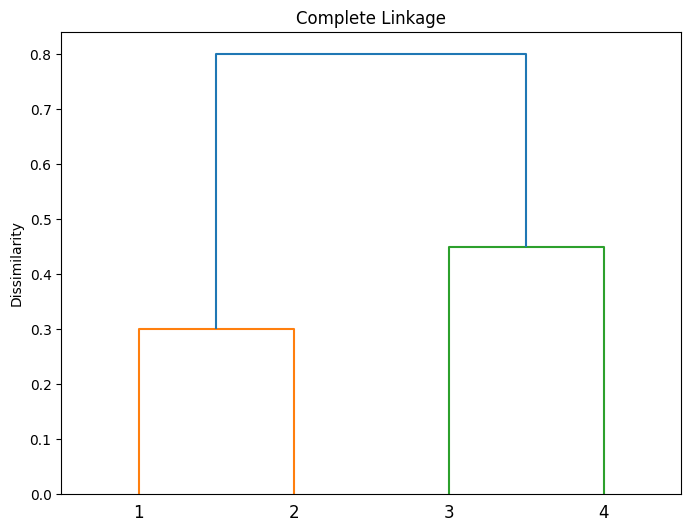

In [138]:
D = np.array([
    [0.0, 0.3, 0.4, 0.7],
    [0.3, 0.0, 0.5, 0.8],
    [0.4, 0.5, 0.0, 0.45],
    [0.7, 0.8, 0.45, 0.0]
])

dist_vec = squareform(D)

Z_comp = linkage(dist_vec, method='complete')

plt.figure(figsize=(8, 6))
dendrogram(Z_comp, labels=["1","2","3","4"])
plt.title("Complete Linkage")
plt.ylabel("Dissimilarity")
plt.show()


- Observations 1 and 2 merge first at a dissimilarity of 0.3.

- Observations 3 and 4 merge next at a dissimilarity of 0.45.

- Finally, the two clusters {1, 2} and {3, 4} merge at a dissimilarity of 0.8,

### (b) Single linkage
sketch the dendrogram that results from hierarchically clustering these four observations using single linkage

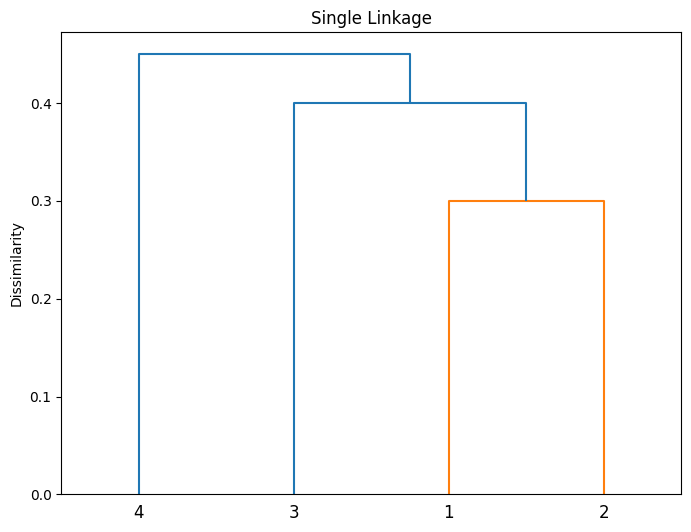

In [139]:
Z_sin = linkage(dist_vec, method='single')

plt.figure(figsize=(8, 6))
dendrogram(Z_sin, labels=["1","2","3","4"])
plt.title("Single Linkage")
plt.ylabel("Dissimilarity")
plt.show()

- Observations 1 and 2 merge first at a dissimilarity of 0.3

- The cluster {1, 2} then merges with observation 3 at a dissimilarity of 0.4

- Finally, the cluster {1, 2, 3} merges with observation 4 at a dissimilarity of 0.45

Note that here the horizontal axis has a different order than 3(a). This is because the ``dendrogram()`` function automatically reorders the leaves to optimize the layout.

### (c) Cut the dendrogram in (a)

If we cut the dendrogram in (a) to obtain two clusters result, we will need to cut at a height between 0.45 and 0.8. After the cut, there will be two clusters:

- Cluster 1: {1, 2}
- Cluster 2: {3, 4}

### (d) Cut the dendrogram in (b)

If we cut the dendrogram in (b) to obtain two clusters result, we have to cut at a height between 0.4 and 0.45. After the cut, there will be two clusters:

- Cluster 1: {1, 2, 3}
- Cluster 2: {4}

### (e) Equivalent dendrogram

Note that the ``dendrogram()`` function automatically provide the optimal layout. I will manually draw the equivalent dendrogram with different label order but the same merge steps.

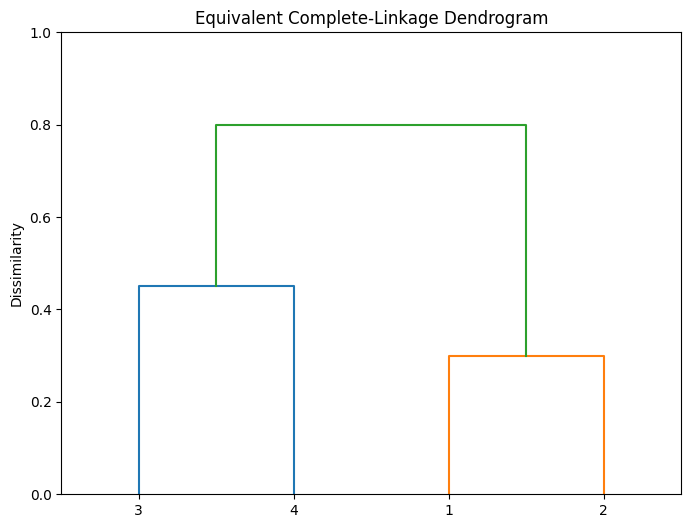

In [140]:
plt.figure(figsize=(8,6))

x = [1, 2, 3, 4]
labels = ["3", "4", "1", "2"]

plt.xticks(x, labels)

plt.plot([1, 1, 2, 2], [0, 0.45, 0.45, 0])
plt.plot([3, 3, 4, 4], [0, 0.3, 0.3, 0])
plt.plot([1.5, 1.5, 3.5, 3.5], [0.45, 0.8, 0.8, 0.3])

plt.ylim(0, 1)
plt.xlim(0.5, 4.5)
plt.title("Equivalent Complete-Linkage Dendrogram")
plt.ylabel("Dissimilarity")

plt.show()


In this new plot, the labels are in different order, but the merge heights and the cluster relationships are same as what we obtained in (a)

- observations 3 and 4 still merge at height 0.45

- observations 1 and 2 still merge at height 0.3

- and cluster {1,2} and cluster {3,4} still merge at height 0.8

### References:

1. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
2. https://lightning.ai/docs/torchmetrics/stable/classification/exact_match.html
3. https://wiki.cloudfactory.com/docs/mp-wiki/metrics/hamming-score
4. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.hamming_loss.html
5. https://www.geeksforgeeks.org/machine-learning/gaussian-kernel/
6. https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.RBF.html
7. https://machinelearningmastery.com/one-vs-rest-and-one-vs-one-for-multi-class-classification/
8. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
9. https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
10. https://medium.com/@sahin.samia/scikit-learn-pipelines-explained-streamline-and-optimize-your-machine-learning-processes-f17b1beb86a4
11. https://scikit-learn.org/stable/modules/compose.html
12. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
13. https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
14. https://docs.scipy.org/doc//scipy-1.16.2/reference/generated/scipy.spatial.distance.squareform.html
15. https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
16. https://docs.scipy.org/doc//scipy-1.16.2/reference/generated/scipy.cluster.hierarchy.dendrogram.html
17. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
18. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html
